# DRL Task 2: Dynamic programing
### 
**BITS Pilani WILP | Deep Reinforcement Learning**
**Team Number:** 130

**Team Members:**
- DEBASHIS GHOSH
- SOUMYA BISWAS
- TUSHAR KANTI SANTRA
- SHREYADHRITA PANDA
- RAJAT KUMAR SINGH


## Problem Statement
Design and implement a reinforcement learning agent using dynamic programming - Value Iteration or 
Policy Iteration to compute an optimal policy for an autonomous rescue drone operating in a disaster zone. 
The drone must learn how to rescue stranded civilians while managing battery power, avoiding dangerous 
zones, and reaching charging stations when necessary. The problem must be modelled as a finite Markov 
Decision Process (MDP). The student will: 
● Implement a custom Drone Rescue environment.  
● Use dynamic programming to compute the optimal value function and policy.  
● Analyse how state design and reward design affect convergence and rescue efficiency. 

## Step 1. Imports and Setup

In [1]:
import itertools
import random
from collections import defaultdict
import time
import matplotlib.pyplot as plt
import numpy as np

## Step 2. Create the Drone Rescue Environment

The DroneRescueEnv class creates a grid world containing rescue targets (R), charging stations (C), danger zones (D), wind zones (W), and obstacles (X).
The drone starts with a limited battery and must navigate the grid while managing energy and avoiding hazards.

In [2]:
class DroneRescueEnv:
    """ A grid-based environment for a drone rescue mission.
    The drone must navigate to rescue targets while managing
    battery life and avoiding dangers. """

    def __init__(self, student_id: str):
        """Initialize the environment based on the student ID."""

        # Determine grid size based on last digit
        last_digit = int(student_id[-1])
        if last_digit <= 4:
            # If the student ID ends with 0–4 we have used a 5x5 grid
            self.rows, self.cols = 5, 5
            rescue_targets, charging_stations, danger_zones, blocked_cells = 2, 1, 3, 2
            wind_prob = 0.2
            max_steps = 50
        else:
            # If the student ID ends with 5-9 we have used a 6x6 grid
            self.rows, self.cols = 6, 6
            rescue_targets, charging_stations, danger_zones, blocked_cells = 3, 2, 4, 3
            wind_prob = 0.3
            max_steps = 75

        """
        Battery Configuration:
        
        If the student ID ends with an even digit then maximum battery = 10 units 
        else if the student ID ends with an odd digit then maximum battery = 15 units.
        """
        if last_digit % 2 == 0:
            max_battery = 10
        else:
            max_battery = 15

        """
        Assign cell types in the grid:
        
        S - Start position
        F - Free/Safe cell 
        D - Dangerous zone
        R - Rescue target 
        C - Charging station 
        W - Wind zone 
        X - Blocked cell / obstacle 
        A - Start position (agent's current location)
        """
        self.max_battery = max_battery
        self.wind_prob = wind_prob
        self.max_steps = max_steps
        self.grid = [['F' for _ in range(self.cols)] for _ in range(self.rows)]

        # Place start
        self.start = (0,0)
        self.grid[0][0] = 'S'

        # Random placements
        self.rescue_positions = self._place('R', rescue_targets)
        self.charging_positions = self._place('C', charging_stations)
        self.danger_positions = self._place('D', danger_zones)
        self.blocked_positions = self._place('X', blocked_cells)
        self.wind_positions = self._place('W', 1)

        self.reset()

    def _place(self, symbol, count):
        """ Helper function to randomly place symbols in the grid. """
        placed = []
        while len(placed) < count:
            r, c = random.randint(0,self.rows-1), random.randint(0,self.cols-1)
            if self.grid[r][c] == 'F':
                self.grid[r][c] = symbol
                placed.append((r,c))
        return placed

    def reset(self):
        """
        Reset the environment to the initial state.
        :return: The current state of the environment after reset
        """
        self.pos = self.start
        self.battery = self.max_battery
        self.steps = 0
        self.rescued = {pos: False for pos in self.rescue_positions}
        self.visited_states = set()

        return self._get_state()

    def _get_state(self):
        """Return the current state representation."""
        return self.pos, self.battery, tuple(self.rescued.values())

    def valid_actions(self):
        """Return the list of valid actions."""
        return ['UP','DOWN','LEFT','RIGHT']

    def execute_action(self, action):
        """
        Take an action and return the new state, reward, and done flag.
        The step function is responsible for Drone flying in real environment
        """
        # Update position based on action and environment dynamics
        r, c = self.pos

        # Step penalty as with each action taken, the drone consumes battery and time.
        reward = -1

        # Initialize a done flag to False, it will be set to True if the episode ends due to rescue completion or max steps reached.
        done = False

        # Increment step count
        self.steps += 1

        # Battery cost
        self.battery -= 1
        if self.battery <= 0:
            """If the battery is depleted, the drone cannot move and receives a large negative reward."""
            return self._get_state(), -20, True

        # Wind disturbance
        if self.grid[r][c] == 'W' and action != 'HOVER':
            """In a wind zone, there's a chance the drone's intended action is overridden by a random movement."""
            if random.random() < self.wind_prob:
                action = random.choice(['UP','DOWN','LEFT','RIGHT'])

        # Movement
        if action == 'UP': r -= 1
        elif action == 'DOWN': r += 1
        elif action == 'LEFT': c -= 1
        elif action == 'RIGHT': c += 1
        elif action == 'HOVER':
            if self.grid[r][c] == 'C':
                """ Hovering on a charging station restores some battery. """
                self.battery = min(self.max_battery, self.battery+2)

        # Boundary check
        if not (0 <= r < self.rows and 0 <= c < self.cols):
            """ If the drone tries to move outside the grid, it stays in place """
            r, c = self.pos

        # Blocked cell check
        if self.grid[r][c] == 'X':
            """ If the drone tries to move into a blocked cell, it stays in place """
            r, c = self.pos

        """ Update position after movement checks """
        self.pos = (r,c)

        """ State visitation penalty to encourage exploration. """
        current_state = self._get_state()
        if current_state in self.visited_states:
            reward -= 10
        self.visited_states.add(current_state)

        # Rewards
        cell = self.grid[r][c]
        if cell == 'R' and not self.rescued[(r,c)]:
            reward += 20
            self.rescued[(r,c)] = True
        elif cell == 'D':
            reward += -10
        elif cell == 'C':
            reward += 5
            self.battery = self.max_battery

        # Termination
        if all(self.rescued.values()):
            reward = reward + 500
            done = True
        elif self.steps >= self.max_steps:
            done = True

        return self._get_state(), reward, done

    def render(self):
        """Print the current state of the grid and drone status."""
        for r in range(self.rows):
            row = ""
            for c in range(self.cols):
                if (r,c) == self.pos:
                    row += "A "  # Agent's current position
                else:
                    row += self.grid[r][c] + " "
            print(row)
        print(f"Battery: {self.battery}, Rescued: {self.rescued}, Steps: {self.steps}")

## Step 3 : Compute the Optimal Policy using Value Iteration

The ValueIterationSolver enumerates all possible states (position, battery level, rescue status) and repeatedly applies the Bellman update equation.
It calculates the expected return for every action and determines the optimal action for each state, producing an optimal policy.

Policy Iteration has two separate phases: Policy Evaluation and Policy Improvement. 

Here in this case we have chosen Value Iteration as it is more straightforward to implement 
and often converges faster for smaller state spaces like our grid environment.

In [3]:
class ValueIterationSolver:
    """Solver for the Drone Rescue Environment using Value Iteration."""

    def __init__(self, env, gamma=0.85, theta=1e-3):
        self.env = env
        self.gamma = gamma
        self.theta = theta
        self.V = defaultdict(float)
        self.policy = {}

        self.arrow_map = {
        'UP': '↑',
        'DOWN': '↓',
        'LEFT': '←',
        'RIGHT': '→' }

    def visualize_policy(self):
        battery = env.max_battery
        rescue_status = tuple(False for _ in env.rescue_positions)
    
        print("\nOptimal Policy:\n")
    
        for r in range(self.env.rows):
            row = ""
            for c in range(self.env.cols):
    
                if (r, c) in self.env.blocked_positions:
                    row += " X "
                    continue
    
                state = ((r, c), battery, rescue_status)
    
                action = self.policy.get(state, None)
    
                if (r, c) in self.env.rescue_positions:
                    row += " R "
                elif (r, c) in self.env.charging_positions:
                    row += " C "
                elif (r, c) in self.env.danger_positions:
                    row += " D "
                elif action:
                    row += f" {self.arrow_map[action]} "
                else:
                    row += " ? "
    
            print(row)
            
    def run(self):
        """Run value iteration until convergence."""
        iteration = 0
        while True:
            delta = 0
            for state in self._enumerate_states():
                v = self.V[state]
                self.V[state] = self._best_value(state)
                delta = max(delta, abs(v - self.V[state]))
            iteration += 1
            if delta < self.theta:
                break
        self._extract_policy()
        return iteration, delta


    def _enumerate_states(self):
        """Enumerate all possible states in the environment and return as a list."""
        states = []
        positions = [
            (r, c)
            for r in range(self.env.rows)
            for c in range(self.env.cols)
            if (r, c) not in self.env.blocked_positions
        ]
        batteries = range(1, self.env.max_battery+1)
        rescue_statuses = list(itertools.product([False,True], repeat=len(self.env.rescue_positions)))
        for pos in positions:
            for b in batteries:
                for rs in rescue_statuses:
                    states.append((pos,b,rs))
        return states

    def _best_value(self, state):
        """Calculate the best value for a given state by evaluating all possible actions."""
        best = float('-inf')

        if all(state[2]):
            return 0
        for a in self.env.valid_actions():
            val = self._evaluate_action(state,a)
            best = max(best,val)
        return best

    def _evaluate_action(self, state, action):
        """Calculate the expected return for taking an action in a given state.
        This enables the drone to mentally imagine future rewards before deciding"""


        pos, battery, rescued = state

        if battery <= 0:
            return -100

        r, c = pos # updating row number and column number of the drone

        # Simulate movement
        nr, nc = r, c

        if action == 'UP':
            nr -= 1
        elif action == 'DOWN':
            nr += 1
        elif action == 'LEFT':
            nc -= 1
        elif action == 'RIGHT':
            nc += 1

        # Boundary check
        if not (0 <= nr < self.env.rows and 0 <= nc < self.env.cols):
            nr, nc = r, c

        # Blocked cell check
        if (nr, nc) in self.env.blocked_positions:
            nr, nc = r, c

        battery -= 1

        reward = -1

        rescued_dict = dict(zip(self.env.rescue_positions, rescued))

        cell = self.env.grid[nr][nc]


        # Rescue reward
        if cell == 'R' and not rescued_dict[(nr, nc)]:
            reward += 20
            rescued_dict[(nr, nc)] = True

        # Danger penalty
        elif cell == 'D':
            reward -= 10

        # Charging station
        elif cell == 'C':

            reward += 5

            # Recharge only if battery is sufficiently low
            if battery < self.env.max_battery - 2:
                battery = self.env.max_battery

        # Penalize staying in same state
        if (nr, nc) == pos:
            reward -= 5

        # Battery depletion
        if battery <= 0:
            reward -= 20
            return reward

        # Mission complete
        if all(rescued_dict.values()):
            reward += 500
            return reward

        next_state = ((nr, nc), battery, tuple(rescued_dict.values()))

        return reward + self.gamma * self.V[next_state]

    def _extract_policy(self):
        """Extract the optimal policy from the value function."""

        for state in self._enumerate_states():
            best_action = None
            best_val = float('-inf')
            for a in self.env.valid_actions():
                val = self._evaluate_action(state,a)
                if val > best_val:
                    best_val = val
                    best_action = a
            self.policy[state] = best_action

## Step 4: State-Value Analysis
State-Value Analysis (Heatmap of V*(s))
The heatmap visualizes the optimal value function  for a fixed battery level (maximum battery) and an initial rescue status where no targets have been rescued. Only the drone position is varied. States near rescue targets generally have higher values because they provide immediate rewards and contribute to mission completion. States near charging stations also tend to have elevated values due to battery replenishment. Danger zones exhibit lower values because of associated penalties, while blocked cells are excluded from the state space. The value gradient demonstrates how the optimal policy guides the drone toward rewarding and strategically important regions of the environment.

In [7]:
class StateValueAnalyzer:
    """
    Visualize the optimal state value function V*(s)
    across the grid for given battery and rescue status.
    """

    def __init__(self, env, solver):
        self.env = env
        self.solver = solver

    def generate_value_grid(self,
                            battery=None,
                            rescue_status=None):
        """
        Generate a 2D grid of V*(s) values for each cell.
        Blocked cells are marked as NaN.
        """

        if battery is None:
            battery = self.env.max_battery

        if rescue_status is None:
            rescue_status = tuple(
                False for _ in self.env.rescue_positions
            )

        value_grid = np.zeros((self.env.rows, self.env.cols))

        for r in range(self.env.rows):
            for c in range(self.env.cols):

                if (r, c) in self.env.blocked_positions:
                    value_grid[r, c] = np.nan
                    continue
                state = ((r, c), battery, rescue_status)
                value_grid[r, c] = self.solver.V[state]

        return value_grid

    def plot_heatmap(self,
                     battery=None,
                     rescue_status=None):
        """
        Plot a heatmap of V*(s) with markers for rescue
        targets, charging stations, danger zones, and blocked cells.
        """

        value_grid = self.generate_value_grid(battery, rescue_status)

        plt.figure(figsize=(8, 6))

        im = plt.imshow(value_grid)
        plt.colorbar(im, label="V*(s)")

        plt.title("State Value Heatmap\n"
                  f"Battery = {battery if battery else self.env.max_battery}")

        plt.xlabel("Column")
        plt.ylabel("Row")

        # Mark rescue targets
        for r, c in self.env.rescue_positions:
            plt.text(c, r, "R", ha="center", va="center", fontsize=12, fontweight="bold")

        # Mark charging stations
        for r, c in self.env.charging_positions:
            plt.text(c, r, "C", ha="center", va="center", fontsize=12, fontweight="bold")

        # Mark danger zones
        for r, c in self.env.danger_positions:
            plt.text( c, r, "D", ha="center", va="center", fontsize=12, fontweight="bold")

        # Mark blocked cells
        for r, c in self.env.blocked_positions:
            plt.text( c, r, "X", ha="center", va="center", fontsize=12, fontweight="bold")

        plt.tight_layout()
        plt.show()

##### Step 5: Simulate the Rescue Mission

The drone follows the computed policy from the start state.
It collects rewards for rescuing targets and recharging, incurs penalties for dangers and inefficient moves, and continues until all targets are rescued or the episode ends.
Finally, the program displays the total reward, rescue status, remaining battery, and number of steps taken.

In [9]:
student_id = input("Enter your student ID: ")

#initializing the class objects
env = DroneRescueEnv(student_id)
solver = ValueIterationSolver(env)

# recoring the start time 
start_time = time.time()

# Simulate following the optimal policy
env.render()
iteration, delta =  solver.run()
solver.visualize_policy()

state = env.reset()
done = False
total_reward = 0

print("\nStarting Execution")
while not done:
    action = solver.policy[state]
    next_state, reward, done = env.execute_action(action)
    total_reward += reward
    state = next_state
    env.render()

# recording the end time 
end_time = time.time()
runtime = end_time - start_time

print("\nFinal Result:")
print(f"Converged after {iteration} iterations with delta={delta:.6f}")
print(f"Runtime: {runtime}")
print("Total Reward Collected:", total_reward)
print("Rescue Status:", env.rescued)
print("Battery Remaining:", env.battery)
print("Steps Taken:", env.steps)

Enter your student ID:  2025AA05581


A D D W F 
F R F F F 
X F F F F 
C F F F D 
X R F F F 
Battery: 15, Rescued: {(4, 1): False, (1, 1): False}, Steps: 0

Optimal Policy:

 ↓  D  D  ↓  ↓ 
 →  R  ←  ←  ← 
 X  ↑  ↑  ↑  ↑ 
 C  ↓  ↓  ↓  D 
 X  R  ←  ←  ← 

Starting Execution
S D D W F 
A R F F F 
X F F F F 
C F F F D 
X R F F F 
Battery: 14, Rescued: {(4, 1): False, (1, 1): False}, Steps: 1
S D D W F 
F A F F F 
X F F F F 
C F F F D 
X R F F F 
Battery: 13, Rescued: {(4, 1): False, (1, 1): True}, Steps: 2
S D D W F 
F R F F F 
X A F F F 
C F F F D 
X R F F F 
Battery: 12, Rescued: {(4, 1): False, (1, 1): True}, Steps: 3
S D D W F 
F R F F F 
X F F F F 
C A F F D 
X R F F F 
Battery: 11, Rescued: {(4, 1): False, (1, 1): True}, Steps: 4
S D D W F 
F R F F F 
X F F F F 
C F F F D 
X A F F F 
Battery: 10, Rescued: {(4, 1): True, (1, 1): True}, Steps: 5

Final Result:
Converged after 7 iterations with delta=0.000000
Runtime: 0.1793994903564453
Total Reward Collected: 535
Rescue Status: {(4, 1): True, (1, 1): True}
Battery Remaini

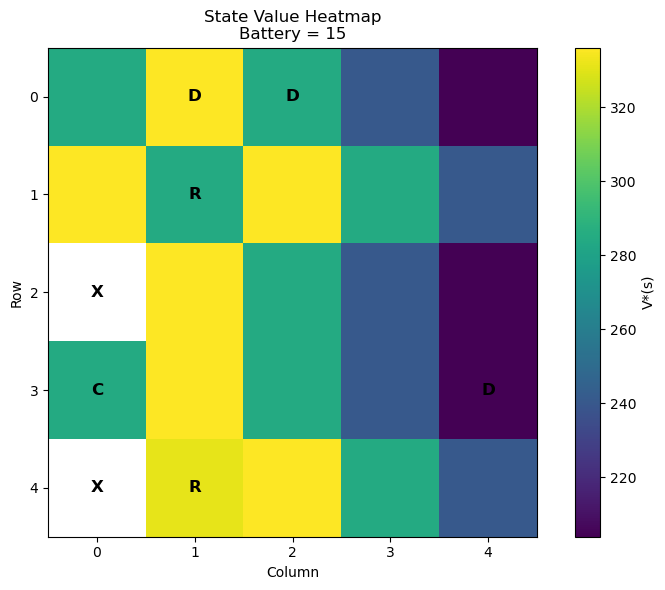

In [10]:
# Plot the state value heatmap
analyzer = StateValueAnalyzer(env, solver)
analyzer.plot_heatmap()

# Discussions 
## DP Scalability Discussion

In our implementation, the state is represented as:

        State=(Position,Battery Level,Rescue Status)

Specifically, in _enumerate_states():
Position = all valid grid cells
Battery = 1 to max_battery
Rescue Status = every combination of rescued/not rescued targets

Therefore:
∣S∣=(Valid Grid Cells)×(Battery States)×(2^Number of Rescue Targets)


1. Curse of Dimensionality

- In this code, the state consists of position + battery level + rescue status.
- Increasing the grid size (10×10), adding more rescue targets, or introducing dynamic weather greatly increases the number of possible states.
- Rescue targets are especially costly because the state space grows exponentially as 2^n.

2. Why Dynamic Programming Becomes Difficult

- Value Iteration must enumerate and evaluate every possible state in _enumerate_states().
- Larger state spaces require more memory, more computation, and more iterations to converge.
- For large environments, exact DP methods become impractical.

3. How Deep RL Helps & Real-World Relevance

- Deep RL uses neural networks to approximate values/policies instead of storing values for every state.
- It can handle large grids, many targets, dynamic weather, and continuous sensor data.
- Real autonomous rescue drones operate in highly complex environments, making Deep RL more scalable and practical than traditional DP methods.